In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# Baseline Model Kurs (Time-Series Only)

# 1. Load & Sortir Data

In [29]:
bi_raw = pd.read_csv('../data/raw/bi-usd-rate.csv')

start_date = pd.Timestamp("2021-09-01")
end_date = pd.Timestamp("2026-09-01")

# Gabungkan tanggal dan jam untuk satu kolom datetime kanonik
bi_raw["Tanggal"] = pd.to_datetime(
    bi_raw["Tanggal"].astype(str).str.strip(),
    format="%m/%d/%Y %I:%M:%S %p",  # perhatikan ada detik (:%S) di format aslinya
    errors="coerce",
)

print(bi_raw.shape)
bi_raw.head(3)

(1202, 5)


,NO,Nilai,Kurs Jual,Kurs Beli,Tanggal
0,1,1,17834.73,17657.27,2026-09-01
1,2,1,17791.51,17614.49,2026-08-31
2,3,1,17850.81,17673.19,2026-08-28


In [30]:
def clean_numeric(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace(",", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce")


bi_raw["Kurs Jual"] = clean_numeric(bi_raw["Kurs Jual"])
bi_raw["Kurs Beli"] = clean_numeric(bi_raw["Kurs Beli"])
bi_raw["NO"] = pd.to_numeric(bi_raw["NO"], errors="coerce")
bi_raw["Nilai"] = pd.to_numeric(bi_raw["Nilai"], errors="coerce")

print(f"Baris awal BI                 : {len(bi_raw)}")

bi = bi_raw.loc[bi_raw["Tanggal"].between(start_date, end_date, inclusive="both")]
print(f"Setelah filter rentang tanggal: {len(bi)}")

mask_valid_numeric = (
    bi["Kurs Jual"].notna()
    & bi["Kurs Beli"].notna()
    & (bi["Kurs Jual"] > 0)
    & (bi["Kurs Beli"] > 0)
)
bi = bi.loc[mask_valid_numeric]
print(f"Setelah filter numerik valid  : {len(bi)}")

mask_valid_spread = bi["Kurs Jual"] > bi["Kurs Beli"]
bi = bi.loc[mask_valid_spread]
print(f"Setelah filter Jual > Beli    : {len(bi)}")

bi = (
    bi.sort_values("Tanggal")
    .drop_duplicates(subset=["Tanggal"], keep="last")
    .reset_index(drop=True)
)
print(f"Setelah dedup tanggal         : {len(bi)}")

bi.head(3)

Baris awal BI                 : 1202
Setelah filter rentang tanggal: 1202
Setelah filter numerik valid  : 1202
Setelah filter Jual > Beli    : 1202
Setelah dedup tanggal         : 1202


,NO,Nilai,Kurs Jual,Kurs Beli,Tanggal
0,1202,1,14377.53,14234.47,2021-09-01
1,1201,1,14355.42,14212.58,2021-09-02
2,1200,1,14352.41,14209.60,2021-09-03


# 2. Exploratory Data Analysis

<class 'pandas.DataFrame'>
RangeIndex: 1202 entries, 0 to 1201
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   NO         1202 non-null   int64         
 1   Nilai      1202 non-null   int64         
 2   Kurs Jual  1202 non-null   float64       
 3   Kurs Beli  1202 non-null   float64       
 4   Tanggal    1202 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(2)
memory usage: 47.1 KB

Jumlah missing value per kolom:
NO           0
Nilai        0
Kurs Jual    0
Kurs Beli    0
Tanggal      0
dtype: int64


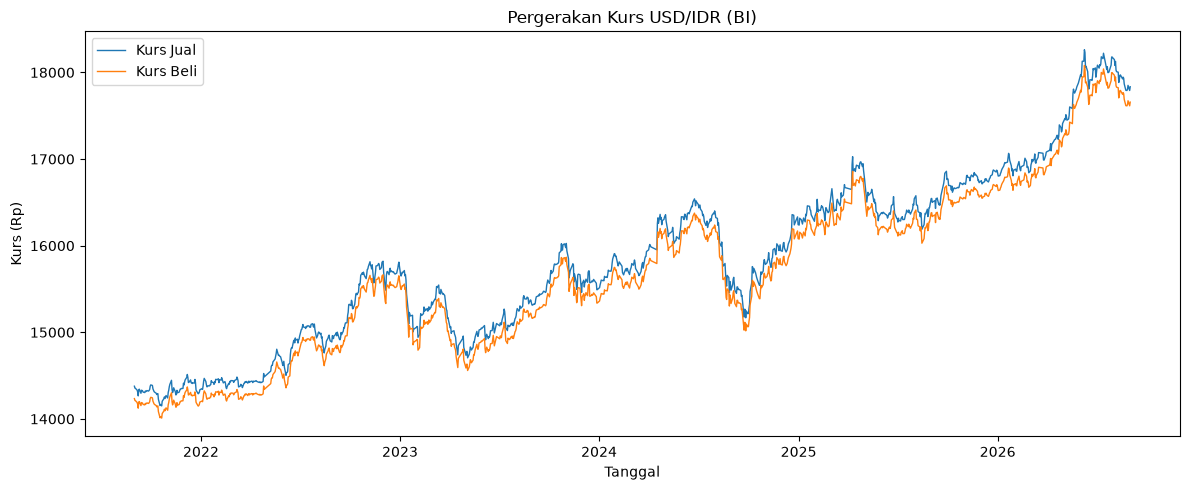

count    1202.000000
mean      157.390948
std         9.753284
min       140.800000
25%       149.825000
50%       156.490000
75%       163.830000
max       181.700000
Name: spread, dtype: float64


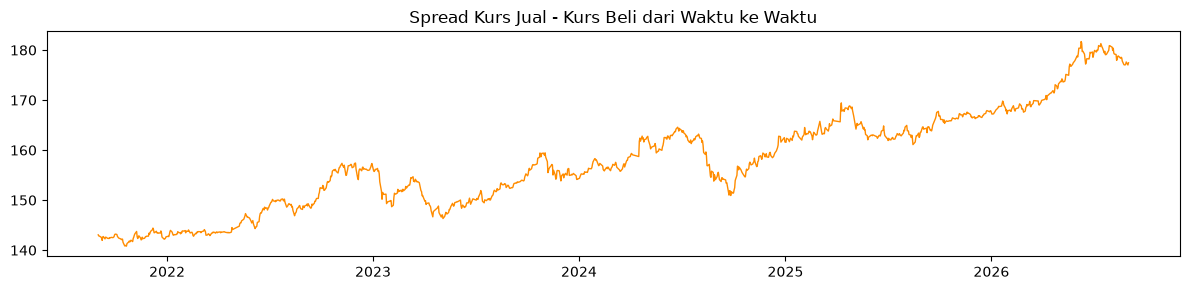

Distribusi jarak antar tanggal (hari):
Tanggal
1.0     922
2.0      18
3.0     223
4.0      18
5.0      13
6.0       2
8.0       2
11.0      2
12.0      1
Name: count, dtype: int64

Jumlah gap > 4 hari: 20
Threshold outlier (3 std): 159.32
Jumlah baris outlier: 21
Baris final untuk modeling : 1202
Rentang tanggal            : 2021-09-01 s.d. 2026-09-01


In [31]:
# Info & Missing Values
bi.info()
print("\nJumlah missing value per kolom:")
print(bi.isna().sum())

# Statistik Deskriptif
bi[["Kurs Jual", "Kurs Beli"]].describe()

# Visualisasi Tren Kurs
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(bi["Tanggal"], bi["Kurs Jual"], label="Kurs Jual", linewidth=1)
ax.plot(bi["Tanggal"], bi["Kurs Beli"], label="Kurs Beli", linewidth=1)
ax.set_title("Pergerakan Kurs USD/IDR (BI)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Kurs (Rp)")
ax.legend()
plt.tight_layout()
plt.show()

# Selisih Kurs Jual - Kurs Beli
# Ini untuk lihat apakah Spread kurs stabil dan wajar 
bi["spread"] = bi["Kurs Jual"] - bi["Kurs Beli"]
print(bi["spread"].describe())

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(bi["Tanggal"], bi["spread"], linewidth=1, color="darkorange")
ax.set_title("Spread Kurs Jual - Kurs Beli dari Waktu ke Waktu")
plt.tight_layout()
plt.show()

# Cek Gap Tanggal
gap = bi["Tanggal"].diff().dt.days
print("Distribusi jarak antar tanggal (hari):")
print(gap.value_counts().sort_index())

gap_besar = bi.loc[gap > 4, ["Tanggal"]].copy()
gap_besar["gap_hari"] = gap[gap > 4]
print(f"\nJumlah gap > 4 hari: {len(gap_besar)}")
gap_besar.head(10)

# Cek outlier 
bi_sorted = bi.sort_values("Tanggal").reset_index(drop=True)
daily_change = bi_sorted["Kurs Jual"].diff()

threshold = daily_change.std() * 3
outliers = bi_sorted.loc[daily_change.abs() > threshold, ["Tanggal", "Kurs Jual"]].copy()
outliers["perubahan"] = daily_change[daily_change.abs() > threshold]

print(f"Threshold outlier (3 std): {threshold:.2f}")
print(f"Jumlah baris outlier: {len(outliers)}")
outliers

bi_raw = bi.rename(columns={"Tanggal": "Tanggal_dt"}).reset_index(drop=True)

print(f"Baris final untuk modeling : {len(bi_raw)}")
print(f"Rentang tanggal            : {bi_raw['Tanggal_dt'].min().date()} s.d. {bi_raw['Tanggal_dt'].max().date()}")

# 3. Kurs Tengah

In [32]:
bi_raw["Kurs Tengah"] = (bi_raw["Kurs Jual"] + bi_raw["Kurs Beli"]) / 2
bi_raw[["Tanggal_dt", "Kurs Jual", "Kurs Beli", "Kurs Tengah"]].head(5)

bi_raw = bi_raw.drop(columns=["Kurs Jual", "Kurs Beli"])

# 4. Formulasi Target (NAIK/TURUN)

In [33]:
df_model = bi_raw.copy()

#target: apakah kurs tengah hari trading berikutnya lebih tinggi dari hari ini
df_model["kurs Next"] = df_model["Kurs Tengah"].shift(-1)
df_model["Target"] = (df_model["kurs Next"] > df_model["Kurs Tengah"]).astype(int)

#baris terakhir tidak punya kurs_next, dibuang
df_model = df_model.iloc[:-1].copy()

print("Distribusi target (1=NAIK, 0=TURUN/TETAP):")
print(df_model["Target"].value_counts(normalize=True))

df_model.tail(5)

Distribusi target (1=NAIK, 0=TURUN/TETAP):
Target
1    0.553705
0    0.446295
Name: proportion, dtype: float64


,NO,Nilai,Tanggal_dt,spread,Kurs Tengah,kurs Next,Target
1196,6,1,2026-08-24,177.06,17705.0,17703.0,0
1197,5,1,2026-08-26,177.02,17703.0,17717.0,1
1198,4,1,2026-08-27,177.16,17717.0,17762.0,1
1199,3,1,2026-08-28,177.62,17762.0,17703.0,0
1200,2,1,2026-08-31,177.02,17703.0,17746.0,1


# 5. Fitur Time-Series (Lag & Rolling)

In [34]:
for lag in range(1, 6):
    df_model[f"kurs_lag{lag}"] = df_model["Kurs Tengah"].shift(lag)

#rolling mean & std 5 hari, dihitung dari shift(1) supaya tidak memakai kurs hari yang sama dengan target
df_model["kurs_roll_mean5"] = df_model["Kurs Tengah"].shift(1).rolling(5).mean()
df_model["kurs_roll_std5"] = df_model["Kurs Tengah"].shift(1).rolling(5).std()

#realized change hari ini vs kemarin, dipakai untuk naive baseline
df_model["kurs_diff1"] = df_model["Kurs Tengah"] - df_model["kurs_lag1"]

TS_FEATURES = [
    "kurs_lag1", "kurs_lag2", "kurs_lag3", "kurs_lag4", "kurs_lag5",
    "kurs_roll_mean5", "kurs_roll_std5",
]

#buang baris awal deret waktu yang belum punya histori lag/rolling lengkap
df_model = df_model.dropna(subset=TS_FEATURES + ["Target"]).reset_index(drop=True)
print(f"Baris setelah dropna fitur lag/rolling : {len(df_model)}")
df_model[["Tanggal_dt", "Kurs Tengah"] + TS_FEATURES + ["Target"]].head(5)

Baris setelah dropna fitur lag/rolling : 1196


,Tanggal_dt,Kurs Tengah,kurs_lag1,kurs_lag2,kurs_lag3,kurs_lag4,kurs_lag5,kurs_roll_mean5,kurs_roll_std5,Target
0,2021-09-08,14195.005,14239.005,14261.005,14281.005,14284.000,14306.000,14274.203,25.329746,1
1,2021-09-09,14266.000,14195.005,14239.005,14261.005,14281.005,14284.000,14252.004,36.618575,1
2,2021-09-10,14272.000,14266.000,14195.005,14239.005,14261.005,14281.005,14248.404,33.432858,0
3,2021-09-13,14225.005,14272.000,14266.000,14195.005,14239.005,14261.005,14246.603,31.419548,1
4,2021-09-14,14260.000,14225.005,14272.000,14266.000,14195.005,14239.005,14239.403,31.418975,0


# 6. Split Data Kronologis (Train/Val/Test)

In [35]:
#split 70/15/15 berurutan waktu, bukan random shuffle
n_rows = len(df_model)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_df = df_model.iloc[:train_end]
val_df = df_model.iloc[train_end:val_end]
test_df = df_model.iloc[val_end:]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Periode train : {train_df['Tanggal_dt'].min().date()} s.d. {train_df['Tanggal_dt'].max().date()}")
print(f"Periode test  : {test_df['Tanggal_dt'].min().date()} s.d. {test_df['Tanggal_dt'].max().date()}")

Train: 837 | Val: 179 | Test: 180
Periode train : 2021-09-08 s.d. 2025-02-19
Periode test  : 2025-11-24 s.d. 2026-08-31


# 7. Fungsi Evaluasi

In [36]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "model": model_name,
        "directional_accuracy": accuracy_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "MSE": mse,
        "RMSE": rmse
    }

results = []

# 8. Persiapan Fitur & Label

In [37]:
X_train, y_train = train_df[TS_FEATURES], train_df["Target"]
X_val, y_val = val_df[TS_FEATURES], val_df["Target"]
X_test, y_test = test_df[TS_FEATURES], test_df["Target"]

# 9. Model 1 — Naive / Persistence Baseline

In [38]:
#opsi A: arah = sesuai perubahan hari sebelumnya (kurs_diff1)
def naive_predict(df):
    return (df["kurs_diff1"] > 0).astype(int)

y_pred_naive_val = naive_predict(val_df)
y_pred_naive_test = naive_predict(test_df)

results.append(evaluate_model(y_val, y_pred_naive_val, "Naive (Persistence Arah) - Val"))
results.append(evaluate_model(y_test, y_pred_naive_test, "Naive (Persistence Arah) - Test"))

#opsi B: selalu prediksi kelas mayoritas di train (pembanding lower-bound)
majority_class = int(y_train.mode()[0])
y_pred_majority_val = np.full(len(y_val), majority_class)
y_pred_majority_test = np.full(len(y_test), majority_class)

results.append(evaluate_model(y_val, y_pred_majority_val, "Naive (Majority Class) - Val"))
results.append(evaluate_model(y_test, y_pred_majority_test, "Naive (Majority Class) - Test"))

pd.DataFrame(results)


,model,directional_accuracy,f1_score,MSE,RMSE
0,Naive (Persistence Arah) - Val,0.513966,0.539683,0.486034,0.697161
1,Naive (Persistence Arah) - Test,0.550000,0.608696,0.450000,0.670820
2,Naive (Majority Class) - Val,0.525140,0.688645,0.474860,0.689101
3,Naive (Majority Class) - Test,0.577778,0.732394,0.422222,0.649786


# 10. Model 2 — Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg_val = logreg.predict(X_val_scaled)
y_pred_logreg_test = logreg.predict(X_test_scaled)

results.append(evaluate_model(y_val, y_pred_logreg_val, "Logistic Regression - Val"))
results.append(evaluate_model(y_test, y_pred_logreg_test, "Logistic Regression - Test"))

pd.DataFrame(results)


,model,directional_accuracy,f1_score,MSE,RMSE
0,Naive (Persistence Arah) - Val,0.513966,0.539683,0.486034,0.697161
1,Naive (Persistence Arah) - Test,0.550000,0.608696,0.450000,0.670820
2,Naive (Majority Class) - Val,0.525140,0.688645,0.474860,0.689101
3,Naive (Majority Class) - Test,0.577778,0.732394,0.422222,0.649786
4,Logistic Regression - Val,0.547486,0.649351,0.452514,0.672692
5,Logistic Regression - Test,0.555556,0.560440,0.444444,0.666667


# 11. Model 3 — Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf_val = rf.predict(X_val)
y_pred_rf_test = rf.predict(X_test)

results.append(evaluate_model(y_val, y_pred_rf_val, "Random Forest - Val"))
results.append(evaluate_model(y_test, y_pred_rf_test, "Random Forest - Test"))

pd.DataFrame(results)

,model,directional_accuracy,f1_score,MSE,RMSE
0,Naive (Persistence Arah) - Val,0.513966,0.539683,0.486034,0.697161
1,Naive (Persistence Arah) - Test,0.550000,0.608696,0.450000,0.670820
2,Naive (Majority Class) - Val,0.525140,0.688645,0.474860,0.689101
3,Naive (Majority Class) - Test,0.577778,0.732394,0.422222,0.649786
4,Logistic Regression - Val,0.547486,0.649351,0.452514,0.672692
5,Logistic Regression - Test,0.555556,0.560440,0.444444,0.666667
6,Random Forest - Val,0.480447,0.162162,0.519553,0.720800
7,Random Forest - Test,0.422222,0.000000,0.577778,0.760117


# 12. Model 4 — XGBoost (Classifier)

In [41]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=50,
)
xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
print(f"Berhenti di iterasi ke-{xgb_clf.best_iteration} dari maksimum 2000 (early stopping)")

y_pred_xgbclf_val = xgb_clf.predict(X_val)
y_pred_xgbclf_test = xgb_clf.predict(X_test)

results.append(evaluate_model(y_val, y_pred_xgbclf_val, "XGBoost - Val"))
results.append(evaluate_model(y_test, y_pred_xgbclf_test, "XGBoost - Test"))

pd.DataFrame(results)

Berhenti di iterasi ke-1 dari maksimum 2000 (early stopping)


,model,directional_accuracy,f1_score,MSE,RMSE
0,Naive (Persistence Arah) - Val,0.513966,0.539683,0.486034,0.697161
1,Naive (Persistence Arah) - Test,0.550000,0.608696,0.450000,0.670820
2,Naive (Majority Class) - Val,0.525140,0.688645,0.474860,0.689101
3,Naive (Majority Class) - Test,0.577778,0.732394,0.422222,0.649786
4,Logistic Regression - Val,0.547486,0.649351,0.452514,0.672692
5,Logistic Regression - Test,0.555556,0.560440,0.444444,0.666667
6,Random Forest - Val,0.480447,0.162162,0.519553,0.720800
7,Random Forest - Test,0.422222,0.000000,0.577778,0.760117
8,XGBoost - Val,0.525140,0.688645,0.474860,0.689101
9,XGBoost - Test,0.577778,0.732394,0.422222,0.649786


# 13. Model 5 — LightGBM

In [42]:
lgbm_clf = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbosity=-1,
)

lgbm_clf.fit(
    X_train,
    y_train,
    eval_X=X_val,
    eval_y=y_val,
    callbacks=[
        early_stopping(50, verbose=False),
        log_evaluation(0)
    ],
)

print(
    f"Berhenti di iterasi ke-{lgbm_clf.best_iteration_} "
    f"dari maksimum 2000 (early stopping)"
)

y_pred_lgbm_val = lgbm_clf.predict(X_val)
y_pred_lgbm_test = lgbm_clf.predict(X_test)

results.append(
    evaluate_model(
        y_val,
        y_pred_lgbm_val,
        "LightGBM - Val"
    )
)

results.append(
    evaluate_model(
        y_test,
        y_pred_lgbm_test,
        "LightGBM - Test"
    )
)

pd.DataFrame(results)

Berhenti di iterasi ke-16 dari maksimum 2000 (early stopping)


,model,directional_accuracy,f1_score,MSE,RMSE
0,Naive (Persistence Arah) - Val,0.513966,0.539683,0.486034,0.697161
1,Naive (Persistence Arah) - Test,0.550000,0.608696,0.450000,0.670820
2,Naive (Majority Class) - Val,0.525140,0.688645,0.474860,0.689101
3,Naive (Majority Class) - Test,0.577778,0.732394,0.422222,0.649786
4,Logistic Regression - Val,0.547486,0.649351,0.452514,0.672692
5,Logistic Regression - Test,0.555556,0.560440,0.444444,0.666667
6,Random Forest - Val,0.480447,0.162162,0.519553,0.720800
7,Random Forest - Test,0.422222,0.000000,0.577778,0.760117
8,XGBoost - Val,0.525140,0.688645,0.474860,0.689101
9,XGBoost - Test,0.577778,0.732394,0.422222,0.649786


# 14. Model 6 — Elastic Net

In [43]:
enet = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    max_iter=5000,
    random_state=42,
)
enet.fit(X_train_scaled, y_train)

y_pred_enet_val = enet.predict(X_val_scaled)
y_pred_enet_test = enet.predict(X_test_scaled)

results.append(evaluate_model(y_val, y_pred_enet_val, "Elastic Net - Val"))
results.append(evaluate_model(y_test, y_pred_enet_test, "Elastic Net - Test"))

pd.DataFrame(results)

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,directional_accuracy,f1_score,MSE,RMSE
0,Naive (Persistence Arah) - Val,0.513966,0.539683,0.486034,0.697161
1,Naive (Persistence Arah) - Test,0.550000,0.608696,0.450000,0.670820
2,Naive (Majority Class) - Val,0.525140,0.688645,0.474860,0.689101
3,Naive (Majority Class) - Test,0.577778,0.732394,0.422222,0.649786
4,Logistic Regression - Val,0.547486,0.649351,0.452514,0.672692
5,Logistic Regression - Test,0.555556,0.560440,0.444444,0.666667
6,Random Forest - Val,0.480447,0.162162,0.519553,0.720800
7,Random Forest - Test,0.422222,0.000000,0.577778,0.760117
8,XGBoost - Val,0.525140,0.688645,0.474860,0.689101
9,XGBoost - Test,0.577778,0.732394,0.422222,0.649786


# 15. Ringkasan Perbandingan Seluruh Model

In [44]:
results_df = pd.DataFrame(results)
results_df["dataset"] = results_df["model"].apply(lambda x: "Val" if "Val" in x else "Test")
results_df["model"] = results_df["model"].str.replace(" - Val", "").str.replace(" - Test", "")

summary = results_df.pivot(index="model", columns="dataset", values="directional_accuracy")
summary["f1_test"] = results_df[results_df["dataset"] == "Test"].set_index("model")["f1_score"]
summary.sort_values("Test", ascending=False)


dataset,Test,Val,f1_test
model,,,
LightGBM,0.577778,0.530726,0.732394
XGBoost,0.577778,0.525140,0.732394
Naive (Majority Class),0.577778,0.525140,0.732394
Elastic Net,0.566667,0.558659,0.576087
Logistic Regression,0.555556,0.547486,0.560440
Naive (Persistence Arah),0.550000,0.513966,0.608696
Random Forest,0.422222,0.480447,0.000000
